In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4
import datetime as dt
from mpl_toolkits.basemap import Basemap
import gsw
%matplotlib inline
import glob
import pandas as pd
import ArcTools as Atools
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import datetime as dt
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import ArcTools as Atools

### Vertical interpolation function

In [3]:
def interp_prof(x_old, y_old, x_new):

    # Import interpolation methods from SciPy
    # (only Akima1DInterpolator is actually used below)
    from scipy.interpolate import Akima1DInterpolator
    
    yi = []   # list to store interpolated profiles
    iyi = []  # list to store indices of successfully interpolated profiles
    
    # Loop over each profile (rows of y_old)
    for i in range(0, y_old.shape[0]):
        #print(i)
        
        # Extract the i-th profile
        y = y_old[i, :]
        x = x_old
        
        # Identify non-NaN values in y and x_old
        inans_y = ~np.isnan(y)
        inans_x = ~np.isnan(x)
       
        # print(len(inans_x),len(inans_y))
        # Keep only points where both x and y are valid
        inans = inans_y * inans_x
        
        #print('profile number ',i,' number of finite values ',len(y[inans]))
        # Proceed only if there are any valid points
        if np.any(inans):
            
            # Need at least 2 valid points for interpolation
            if len(y[inans]) > 1:
                # print(i)

                # Create Akima spline interpolator using valid data points
                try :
                    spl = Akima1DInterpolator(x[inans], y[inans])
                
                
                    # Interpolate profile onto the new x grid
                    prof = spl(x_new)
                
                    # Store interpolated profile and its original index
                    yi.append(prof)
                    iyi.append(i)
                except ValueError:
                    continue
        else:
            print(i)
                
    # Return:
    # - array of interpolated profiles
    # - array of indices of profiles that were successfully interpolated
    return np.array(yi), np.array(iyi)

### Vertical grid ISAS

In [4]:
# read
dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data


## Files to loop on

In [5]:
DIR_OUT = '/data0/user/aprigent/BGEP/'
import os



list_ctd_BGEP = sorted(glob.glob(DIR_OUT + '*_TS.nc'))
list_ctd_BGEP

['/data0/user/aprigent/BGEP/2004_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2005_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2006_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2007_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2008_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2009_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2010_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2011_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2012_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2013_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2014_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2015_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2016_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2017_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2018_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2019_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2020_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2021_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2022_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2023_ctd_TS.nc',
 '/data0/user/aprigent/BGEP/2024_ctd_TS.nc']

In [6]:

ds_test= xr.open_dataset('/data0/user/aprigent/BGEP/2004_ctd_TS.nc')
ds_test

<xarray.Dataset>
Dimensions:      (pressure: 3912, profile: 50)
Coordinates:
  * pressure     (pressure) float64 1.0 2.0 3.0 ... 3.91e+03 3.911e+03 3.912e+03
    latitude     (profile) float64 ...
    longitude    (profile) float64 ...
    time         (profile) int64 ...
Dimensions without coordinates: profile
Data variables:
    t090C        (profile, pressure) float64 ...
    sal00        (profile, pressure) float64 ...
    source_file  (profile) object ...
Attributes:
    source_file:  d200416_001.cnv

# Start loop on the BGEP netcdf files
netcdf files are created in /Analysis_obs/read_BGEP_CTD_to_netcdf.ipynb

In [7]:
DIR_OUT = '/data0/user/aprigent/BGEP/'
import os



list_ctd_BGEP = sorted(glob.glob(DIR_OUT + '*_TS.nc'))

for f in list_ctd_BGEP:
    print(f)
    ds_tmp = xr.open_dataset(f,decode_times=False)

    basename = os.path.basename(f) 
    name_no_ext = os.path.splitext(basename)[0]
    



    
    pres = ds_tmp.pressure.values
    lat = ds_tmp.latitude.values
    lon = ds_tmp.longitude.values
    psal = ds_tmp.sal00.values
    temp = ds_tmp.t090C.values
    time = ds_tmp.time.values
    source_file = ds_tmp.source_file.values
    platform_id = [int(ds_tmp.source_file.values[i][-7:-4]) for i in range(ds_tmp.source_file.values.shape[0])]
    

    dep = -gsw.z_from_p(
    pres[:, None],   # (depth, 1)
    lat[None, :])     # (1, lat))

    
    
    n_levels_temp = np.ones((dep.shape[1]))*dep.shape[0]
    n_levels_psal  = np.ones((dep.shape[1]))*dep.shape[0]

    sum_temp = np.nansum(temp,axis=1)
    sum_psal  = np.nansum(psal,axis=1)

    sum_dep = np.nansum(dep,axis=0)

    # convert pressure to depth
    # dep = gsw.z_from_p(pres[:], lat)

    # interpolate onto common ISAS depth grid
    psali,ipsal = interp_prof(dep[:,0], psal, zi)
    tempi,itemp = interp_prof(dep[:,0], temp, zi)

    
    if len(ipsal) != len(itemp):
        print('sal/temp mismatch')
    
    PSAL = np.array(psali)
    LONs = np.array(lon)[ipsal]
    LATs = np.array(lat)[ipsal]
    TIMEs = np.array(time)[ipsal]
    source_file_S = np.array(ds_tmp.source_file)[ipsal]
    platform_id_S = np.array(platform_id)[ipsal]
    sum_PSAL  = sum_psal[ipsal]
    n_levels_PSAL = n_levels_psal[ipsal]
    sum_dep_PSAL = sum_dep[ipsal]
    
    
    TEMP = np.array(tempi)
    LONt = np.array(lon)[itemp]
    LATt = np.array(lat)[itemp]
    TIMEt = np.array(time)[itemp]
    source_file_T = np.array(ds_tmp.source_file)[itemp]
    platform_id_T = np.array(platform_id)[itemp]
    sum_TEMP = sum_temp[itemp]
    n_levels_TEMP = n_levels_temp[itemp]
    sum_dep_TEMP = sum_dep[itemp]

    TEMP[TEMP<-2] = np.nan
    TEMP[TEMP>30] = np.nan
    PSAL[PSAL<0] = np.nan
    PSAL[PSAL>40] = np.nan

    print('TEMP mean = ',np.nanmax(TEMP))
    print('TEMP min = ',np.nanmin(TEMP))
    print('PSAL mean = ',np.nanmax(PSAL))
    print('PSAL min = ',np.nanmin(PSAL))

    # PSAL_2d = PSAL[np.newaxis, :]
    # TEMP_2d = PSAL[np.newaxis, :]

    #save TEMP/PSAL file (ISAS grid)
    ds = xr.Dataset({'latitude': (['prof'], LATs),
                     'longitude': (['prof'], LONs),
                     'time': (['prof'], TIMEs),
                     'source_file': (['prof'], source_file_S),
                     'platform_id': (['prof'], platform_id_S),
                     'salinity': (['prof','levels'], PSAL),                             
                     'sum_salinity': (['prof'], sum_PSAL),
                     'sum_levels': (['prof'], sum_dep_PSAL),
                     'nb_levels': (['prof'], n_levels_PSAL),
                     'depth': (['levels'], zi)},
                    coords={'prof': (['prof'], np.arange(0,len(TIMEs))),
                            'levels':(['levels'], zi)})

    # -----------------------
    # Global attributes
    # -----------------------
    ds.attrs['Comments'] = 'BGEP salinity profiles interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
    ds.attrs['title'] = 'BGEP salinity profiles on ISAS vertical grid'
    ds.attrs['source'] = 'BGEP'
    ds.attrs['history'] = 'load_interp_BGEP_CTD.ipynb'

    # -----------------------
    # Variable attributes
    # -----------------------
    ds['latitude'].attrs = {
        'long_name': 'Latitude',
        'units': 'degrees_north',
        'standard_name': 'latitude'
    }

    ds['longitude'].attrs = {
        'long_name': 'Longitude',
        'units': 'degrees_east',
        'standard_name': 'longitude'
    }

    ds['time'].attrs = {
        'long_name': 'Time',
        'units': 'days since 0001-01-01 (Python datetime system)'
    }

    ds['salinity'].attrs = {
        'long_name': 'Practical salinity',
        'units': '1e-3',   
        'standard_name': 'sea_water_practical_salinity (PSS78)'
    }

    ds['depth'].attrs = {
        'long_name': 'Depth',
        'units': 'm',
        'positive': 'down',
        'standard_name': 'depth'
    }


    #
    ds.to_netcdf(DIR_OUT+name_no_ext+'_CTD_ISAS_PSAL.nc')  

    # save file TEMP
    ds = xr.Dataset({'latitude': (['prof'], LATt),
                     'longitude': (['prof'], LONt),
                     'time': (['prof'], TIMEt),
                     'source_file': (['prof'], source_file_T),
                     'temperature': (['prof','levels'], TEMP),
                     'platform_id': (['prof'], platform_id_T),
                     'sum_temperature': (['prof'], sum_TEMP),
                     'sum_levels': (['prof'], sum_dep_TEMP),
                     'nb_levels': (['prof'], n_levels_TEMP),
                     'depth': (['levels'], zi)},
                    coords={'prof': (['prof'], np.arange(0,len(TIMEt))), 'levels':(['levels'], zi)})
    ds.attrs['Comments'] = 'BGEP temperature profiles interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
    ds.attrs['title'] = 'BGEP temperature profiles on ISAS vertical grid'
    ds.attrs['source'] = 'BGEP'
    ds.attrs['history'] = 'load_interp_BGEP_CTD.ipynb'

    # -----------------------
    # Variable attributes
    # -----------------------
    ds['latitude'].attrs = {
        'long_name': 'Latitude',
        'units': 'degrees_north',
        'standard_name': 'latitude'
    }

    ds['longitude'].attrs = {
        'long_name': 'Longitude',
        'units': 'degrees_east',
        'standard_name': 'longitude'
    }

    ds['time'].attrs = {
        'long_name': 'Time',
        'units': 'days since 0001-01-01 (Python datetime system)'
    }

    ds['temperature'].attrs = {
        'long_name': 'In-situ temperature T90',
        'units': 'degC',
        'standard_name': 'sea_water_temperature'
    }

    ds['depth'].attrs = {
        'long_name': 'Depth',
        'units': 'm',
        'positive': 'down',
        'standard_name': 'depth'
    }


#
    ds.to_netcdf(DIR_OUT+name_no_ext+'_CTD_ISAS_TEMP.nc')

/data0/user/aprigent/BGEP/2004_ctd_TS.nc
TEMP mean =  5.634131802526487
TEMP min =  -1.7039817759559475
PSAL mean =  34.95787091560815
PSAL min =  6.989164294461868
/data0/user/aprigent/BGEP/2005_ctd_TS.nc
TEMP mean =  4.975714953686278
TEMP min =  -1.6613539451381085
PSAL mean =  34.95717621868981
PSAL min =  12.629016841015464
/data0/user/aprigent/BGEP/2006_ctd_TS.nc
TEMP mean =  13.980743030591725
TEMP min =  -1.7785514656655812
PSAL mean =  34.9576
PSAL min =  2.127086108102294
/data0/user/aprigent/BGEP/2007_ctd_TS.nc
TEMP mean =  10.758486318282177
TEMP min =  -1.6430113963493074
PSAL mean =  34.95840035201887
PSAL min =  15.69181974709208
/data0/user/aprigent/BGEP/2008_ctd_TS.nc
TEMP mean =  8.760836357654624
TEMP min =  -1.6900279987445426
PSAL mean =  34.95689825985384
PSAL min =  18.76476554849376
/data0/user/aprigent/BGEP/2009_ctd_TS.nc
TEMP mean =  4.232350199736792
TEMP min =  -1.7336921172447264
PSAL mean =  34.95661115141976
PSAL min =  21.514878466110094
/data0/user/apri

In [8]:
##########################################################################################
def concat_netcdf_psal(file_list):
    ds = xr.open_dataset(file_list[0],decode_times=False)
    param = ds.salinity.data

    lon = ds.longitude.data
    lat = ds.latitude.data
    time = ds.time.data
    depth = ds.depth.data
    source = ds.source_file.data
    
    for f in file_list[1:]:
        ds = xr.open_dataset(f,decode_times=False)
        param = np.concatenate((param, ds.salinity.data),axis=0)
        lon = np.concatenate((lon, ds.longitude.data),axis=0)
        lat = np.concatenate((lat, ds.latitude.data),axis=0)
        time = np.concatenate((time, ds.time.data),axis=0)
        source_file = np.concatenate((source, ds.source_file.data),axis=0)
        
    return param,lon,lat,time,depth,source_file

##########################################################################################
def concat_netcdf_temp(file_list):
    ds = xr.open_dataset(file_list[0],decode_times=False)
    param = ds.temperature.data
    lon = ds.longitude.data
    lat = ds.latitude.data
    time = ds.time.data
    depth = ds.depth.data
    source = ds.source_file.data
    
    for f in file_list[1:]:
        ds = xr.open_dataset(f,decode_times=False)
        param = np.concatenate((param, ds.temperature.data),axis=0)
        lon = np.concatenate((lon, ds.longitude.data),axis=0)
        lat = np.concatenate((lat, ds.latitude.data),axis=0)
        time = np.concatenate((time, ds.time.data),axis=0)
        source_file = np.concatenate((source, ds.source_file.data),axis=0)
        
    return param,lon,lat,time,depth,source_file

##########################################################################################
def create_merged_dataset_psal(list_psal,source,variable):
    psal,lon_psal,lat_psal,time_psal, dep_psal,source_psal = concat_netcdf_psal(list_psal)


    nprof = len(lat_psal)
    ndepth = len(dep_psal)
    source_array = np.full(nprof, source)  # array of 'UDASH' repeated nprof times
    duplicate_array = np.full(nprof, False)  # array of 'UDASH' repeated nprof times

    ds = xr.Dataset(
        data_vars=dict(
            longitude=("profile", lon_psal),
            latitude=("profile", lat_psal),
            time=("profile",time_psal),
            source=("profile",source_array),
            source_file=("profile",source_psal),
            dataset_index=("profile", np.arange(nprof)),
            is_duplicate = ("profile",duplicate_array),
            salinity=(("profile", "depth"), psal)
            
        ),
        coords=dict(
            profile=np.arange(nprof),
            depth=("depth", dep_psal)
        ),
        attrs=dict(
            title=source+" salinity profiles",
            source=source,
            featureType="profile"
        )
    )
    ds.attrs['Comments'] = source+' temperature profiles interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
    ds["longitude"].attrs = {
        "standard_name": "longitude",
        "units": "degrees_east"
    }

    ds["latitude"].attrs = {
        "standard_name": "latitude",
        "units": "degrees_north"
    }

    ds["time"].attrs = {
        "long_name": "time",
        "description": "Python ordinal day count",
        "units": "days since 0001-01-01 00:00:00",
        "calendar": "proleptic_gregorian"
    }


    ds["depth"].attrs = {
        "standard_name": "depth",
        "units": "m",
        "positive": "down"
    }

    ds["salinity"].attrs = {
        "standard_name": "sea_water_practical_salinity",
        "long_name": "Practical salinity",
        "units": "1e-3"
    }
    ## Ensure that the profile are made north of 65N ##
    ds = ds.where(ds.latitude>65,drop=True)
    return ds


##########################################################################################


def create_merged_dataset_temp(list_psal,source,variable):
    psal,lon_psal,lat_psal,time_psal, dep_psal,source_temp = concat_netcdf_temp(list_psal)


    nprof = len(lat_psal)
    ndepth = len(dep_psal)
    source_array = np.full(nprof, source)  # array of 'UDASH' repeated nprof times
    duplicate_array = np.full(nprof, False)  # array of 'UDASH' repeated nprof times

    ds = xr.Dataset(
        data_vars=dict(
            longitude=("profile", lon_psal),
            latitude=("profile", lat_psal),
            time=("profile",time_psal),
            source=("profile",source_array),
            source_file=("profile",source_temp),
            dataset_index=("profile", np.arange(nprof)),
            is_duplicate = ("profile",duplicate_array),
            temperature=(("profile", "depth"), psal)
            
        ),
        coords=dict(
            profile=np.arange(nprof),
            depth=("depth", dep_psal)
        ),
        attrs=dict(
            title=source+" temperature profiles",
            source=source,
            featureType="profile"
        )
    )
    ds.attrs['Comments'] = source+' temperature profiles interpolated on ISAS vertical levels using a Akima 1D interpolator scheme (scipy)'
    ds["longitude"].attrs = {
        "standard_name": "longitude",
        "units": "degrees_east"
    }

    ds["latitude"].attrs = {
        "standard_name": "latitude",
        "units": "degrees_north"
    }

    ds["time"].attrs = {
        "long_name": "time",
        "description": "Python ordinal day count",
        "units": "days since 0001-01-01 00:00:00",
        "calendar": "proleptic_gregorian"
    }


    ds["depth"].attrs = {
        "standard_name": "depth",
        "units": "m",
        "positive": "down"
    }

    ds["temperature"].attrs = {
        "standard_name": "sea_water_temperature",
        "units": "degC"
    }
    ## Ensure that the profile are made north of 65N ##
    ds = ds.where(ds.latitude>65,drop=True)
    return ds



In [9]:
bgep_path = '/data0/user/aprigent/BGEP/'
bgep_list_psal = glob.glob(bgep_path + '*_ctd_TS_CTD_ISAS_PSAL.nc')
bgep_list_temp = glob.glob(bgep_path + '*_ctd_TS_CTD_ISAS_TEMP.nc')

ds_bgep_psal = Atools.create_merged_dataset_psal(bgep_list_psal,'ARGO','psal')
ds_bgep_temp = Atools.create_merged_dataset_temp(bgep_list_temp,'ARGO','temp')

Text(0.5, 1.0, 'BGEP')

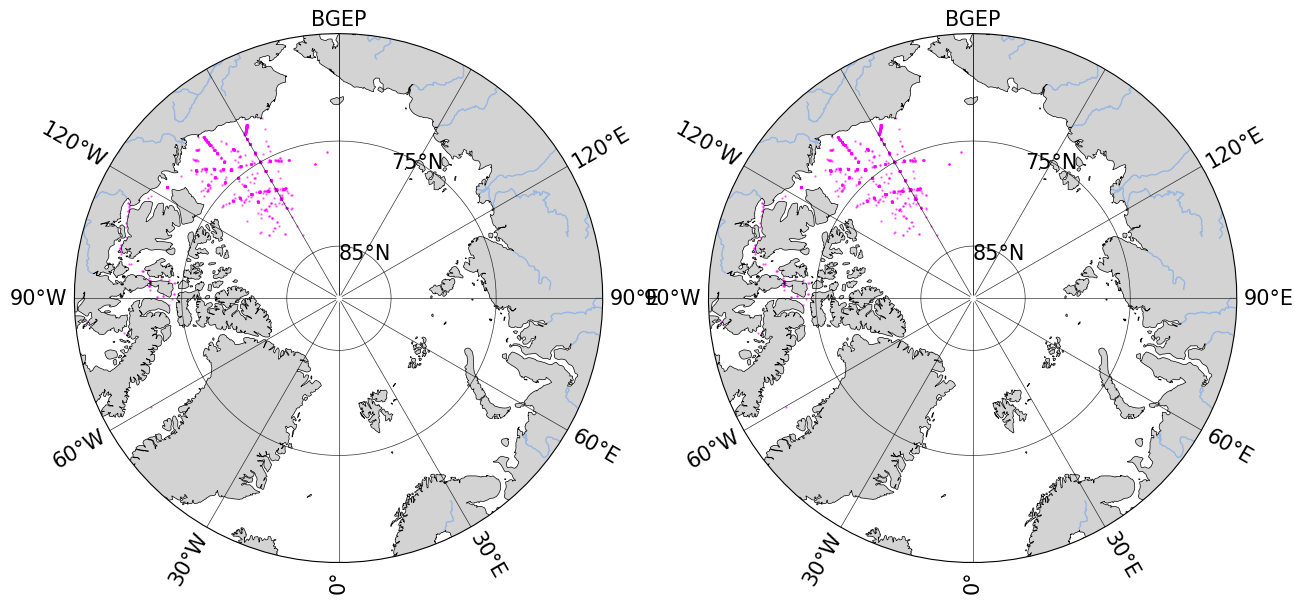

In [10]:


f,ax = plt.subplots(1,2,figsize=[15,10],subplot_kw={'projection': ccrs.NorthPolarStereo()})
ax=ax.ravel()
ftz=15
# cmap = cmocean.cm.deep
# levels = np.arange(-5000,500,500)



Atools.plot_arctic_ax_map_new(ax[0])

ax[0].scatter(ds_bgep_psal.longitude,
           ds_bgep_psal.latitude,
           marker='.',transform=ccrs.PlateCarree(),s=2,color='magenta',label='All',alpha=0.5)
ax[0].set_title('BGEP',fontsize=ftz)



Atools.plot_arctic_ax_map_new(ax[1])

ax[1].scatter(ds_bgep_temp.longitude,
           ds_bgep_temp.latitude,
           marker='.',transform=ccrs.PlateCarree(),s=2,color='magenta',label='All',alpha=0.5)
ax[1].set_title('BGEP',fontsize=ftz)

In [11]:

    
def plot_vertical_distribution(ds_psal, ds_temp, source):

    ftz = 15

    sal = ds_psal.salinity.values
    temp = ds_temp.temperature.values
    depth = ds_psal.depth.values

    n_prof_psal = sal.shape[0]
    n_prof_temp = temp.shape[0]

    finite_per_level_psal = np.sum(np.isfinite(sal), axis=0)
    psal_mean = np.nanmedian(sal, axis=0)
    psal_std = np.nanstd(sal, axis=0)

    finite_per_level_temp = np.sum(np.isfinite(temp), axis=0)
    temp_mean = np.nanmedian(temp, axis=0)
    temp_std = np.nanstd(temp, axis=0)

    f, ax = plt.subplots(2, 2, figsize=[10, 10], sharey=True)
    ax = ax.ravel()
    plt.subplots_adjust(top=1, bottom=0, left=0, right=1, hspace=0.3)
    # ---- SALINITY PROFILES (NO LOOP) ----
    ax[0].scatter(
        sal.ravel(),
        np.tile(depth, n_prof_psal),
        s=1,
        color='blue'
    )

    ax[0].plot(psal_mean, depth, color='red', label=r'median')
    ax[0].plot(psal_mean + psal_std, depth, 'g--', label=r'median $\pm \sigma$')
    ax[0].plot(psal_mean - psal_std, depth, 'g--')
    ax[0].plot(psal_mean + 2*psal_std, depth, 'r--', label=r'median $\pm 2\sigma$')
    ax[0].plot(psal_mean - 2*psal_std, depth, 'r--')

    ax[0].invert_yaxis()
    ax[0].set_ylim([3000, 0])
    ax[0].legend(fontsize=ftz)
    ax[0].set_xlabel("Salinity",fontsize=ftz)
    ax[0].set_ylabel("Depth (m)",fontsize=ftz)
    ax[0].tick_params(labelsize=ftz)
    ax[0].set_title(source,fontsize=ftz)

    # ---- FINITE SALINITY ----
    ax[1].plot(finite_per_level_psal, depth, marker='.', color='black')
    ax[1].set_xlabel("Number of finite values",fontsize=ftz)
    ax[1].tick_params(labelsize=ftz)
    ax11 = ax[1].twiny()
    ax11.plot(finite_per_level_psal / n_prof_psal * 100, depth, color='black')
    ax11.set_xlabel("Fraction valid (%)",fontsize=ftz)
    ax11.tick_params(labelsize=ftz)

    # ---- TEMPERATURE PROFILES (NO LOOP) ----
    ax[2].scatter(
        temp.ravel(),
        np.tile(depth, n_prof_temp),
        s=1,
        color='blue'
    )

    ax[2].plot(temp_mean, depth, color='red', label=r'median')
    ax[2].plot(temp_mean + temp_std, depth, 'g--', label=r'median $\pm \sigma$')
    ax[2].plot(temp_mean - temp_std, depth, 'g--')
    ax[2].plot(temp_mean + 2*temp_std, depth, 'r--', label=r'median $\pm 2\sigma$')
    ax[2].plot(temp_mean - 2*temp_std, depth, 'r--')
    ax[2].set_xlabel("Temperature ($^{\circ}$C)",fontsize=ftz)
    ax[2].set_ylabel("Depth (m)",fontsize=ftz)
    ax[2].axvline(-2,color='magenta',linestyle='--')
    ax[2].legend(fontsize=ftz)
    ax[2].tick_params(labelsize=ftz)
    ax[2].set_title(source,fontsize=ftz)
    ax[2].invert_yaxis()
    ax[2].set_ylim([3000,0])

    # ---- FINITE TEMP ----
    ax[3].plot(finite_per_level_temp, depth, marker='.', color='black')
    ax[3].set_xlabel("Number of finite values",fontsize=ftz)
    ax[3].tick_params(labelsize=ftz)
    ax33 = ax[3].twiny()
    ax33.plot(finite_per_level_temp / n_prof_temp * 100, depth, color='black')
    ax33.set_xlabel("Fraction valid (%)",fontsize=ftz)
    ax33.tick_params(labelsize=ftz)
    return f

/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


CPU times: user 7.51 s, sys: 1.48 s, total: 8.99 s
Wall time: 7.41 s


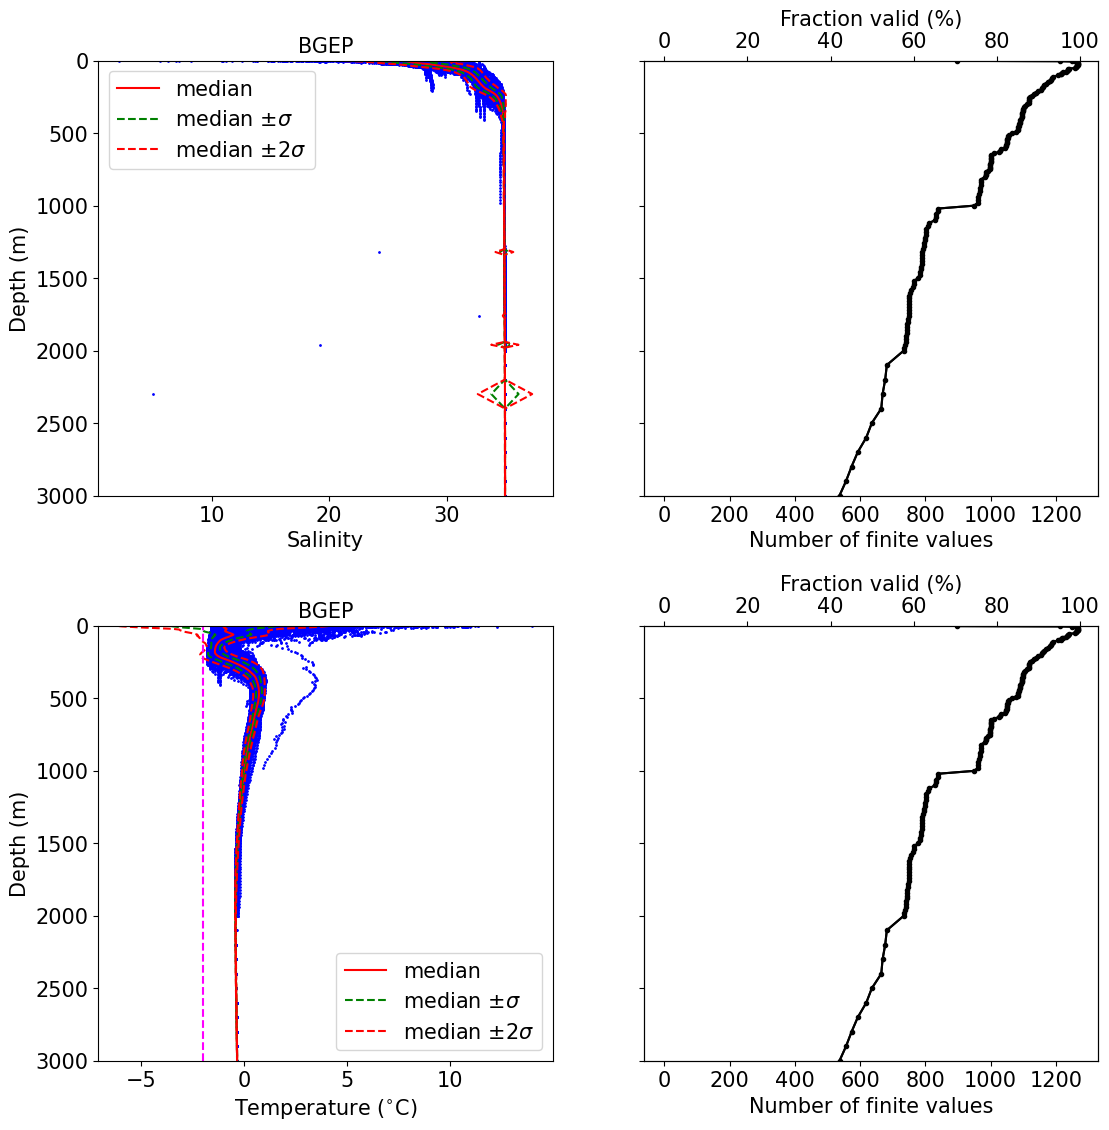

In [12]:
%%time
plot_vertical_distribution(ds_bgep_psal,ds_bgep_temp,source='BGEP')

plt.savefig('/home/aprigent/Documents/Projects/Analysis_obs/figures/fig_data_BGEP_vert_distribution.png',bbox_inches='tight',dpi=300)